## load package


In [2]:

import intake
import cartopy.crs as ccrs
import cartopy.feature as cf
import cmocean
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import easygems.healpix as egh
import xarray as xr
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
from typing import Tuple, List, Optional, Union, Dict
import scipy.signal as signal
from global_land_mask import globe
from metpy.units import units
from metpy.calc import relative_humidity_from_specific_humidity
import time,os,glob,sys,importlib,cmaps,pickle,math,logging
from scipy import fft
import matplotlib.colors as mcolors
sys.path.append("/home/m/m301257/wave_tools")
from wave_tools.utils import dataarray_to_equatorial_latlon_grid,get_region_healpix_,create_cmap_from_string,dataarray_healpix_to_equatorial_latlon
from  wave_tools.plotting import get_cckw_envelope_curve,setup_map_axes,set_axis_for_wave    
# 重新导入修复后的模块
import wave_tools.spectral
import wave_tools.plotting
importlib.reload(wave_tools.spectral)
importlib.reload(wave_tools.plotting)
from wave_tools.spectral import WKSpectralAnalysis, SpectralConfig
from wave_tools.plotting import set_axis_for_wave
from wave_tools import matsuno as mp
print("="*70)
print("✅ 模块重新加载完成")
print("="*70)


DATA_DIR = "./processed_data"
os.makedirs(DATA_DIR, exist_ok=True)
fig_save_dir = "./figures/Cal_qs_qa/"
os.makedirs(fig_save_dir, exist_ok=True)
print("="*70)
print(f"📁 数据保存目录: {DATA_DIR}")
print(f"📁 图形保存目录: {fig_save_dir}")
def create_improved_colormap():
    from matplotlib.colors import LinearSegmentedColormap
    """创建改进的红-白-蓝配色"""
    colors = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
              '#FFFFFF', 
              '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    return LinearSegmentedColormap.from_list('improved_bwr', colors, N=256)

mycmap = create_improved_colormap()

✅ 模块重新加载完成
📁 数据保存目录: ./processed_data
📁 图形保存目录: ./figures/Cal_qs_qa/


In [3]:
def _ocean(ds):
    fraction = xr.open_dataset(os.path.join(DATA_DIR, "ocean_mask_2deg.nc"))['__xarray_dataarray_variable__']
    return fraction == 1

# 计算和比较 qs (饱和比湿) 和 qa (空气比湿)

下面我们要分析 qs 和 qa 在三个实验中的差异，看看湿度梯度 (qs - qa) 是否是控制潜热通量的主导因子。

潜热通量公式: LHF = ρ * Lv * Ce * U * (qs - qa)

其中：
- qs = q_sat(SST, ps)：海表饱和比湿
- qa：近地表空气比湿（2m 或最底层）

In [4]:
# 加载表面比湿数据 (hus - specific humidity at surface/2m level)
# 从你的 hus_*_layers 文件夹中加载最底层的数据

hus_data_dir = '/work/mh1498/m301257/'

# 加载最底层的 specific humidity (应该是 lev_090 或者查看哪个是最底层)
# 先列出 hus_cntl_layers 目录看看有哪些文件
print("Checking hus data files...")
hus_cntl_dir = f'{hus_data_dir}hus_cntl_layers/'
hus_4co2_dir = f'{hus_data_dir}hus_4co2_layers/'
hus_p4k_dir = f'{hus_data_dir}hus_p4k_layers/'

tas_2m_4co2_file = r'/work/mh1498/m301257/processed_data/2d_layers/tas_4co2/tas_2deg_interp.nc'
tas_2m_cntl_file = r'/work/mh1498/m301257/processed_data/2d_layers/tas_cntl/tas_2deg_interp.nc'
tas_2m_p4k_file = r'/work/mh1498/m301257/processed_data/2d_layers/tas_p4k/tas_2deg_interp.nc'

pressure_cntl_file = r'/work/mh1498/m301257/processed_data/2d_layers/ps_cntl/ps_2deg_interp.nc'
pressure_p4k_file = r'/work/mh1498/m301257/processed_data/2d_layers/ps_p4k/ps_2deg_interp.nc'
pressure_4co2_file = r'/work/mh1498/m301257/processed_data/2d_layers/ps_4co2/ps_2deg_interp.nc'

hus2m_cntl_file = r'/work/mh1498/m301257/processed_data/2d_layers/hus2m_cntl/hus2m_2deg_interp.nc'
hus2m_p4k_file = r'/work/mh1498/m301257/processed_data/2d_layers/hus2m_p4k/hus2m_2deg_interp.nc'
hus2m_4co2_file = r'/work/mh1498/m301257/processed_data/2d_layers/hus2m_4co2/hus2m_2deg_interp.nc'

# 列出文件
if os.path.exists(hus_cntl_dir):
    hus_files = sorted([f for f in os.listdir(hus_cntl_dir) if f.endswith('.nc')])
    print(f"Available hus files: {hus_files}")
    
    # 通常最底层是最后一个或者 lev_090
    # 检查是否有 all_levels 文件
    if 'hus_all_levels.nc' in hus_files:
        print("\nFound hus_all_levels.nc - will load and select the lowest level")
    else:
        print(f"\nWill use the highest level number (likely surface): {hus_files[-1]}")

Checking hus data files...
Available hus files: ['hus_all_levels.nc', 'hus_lev_031.nc', 'hus_lev_035.nc', 'hus_lev_038.nc', 'hus_lev_041.nc', 'hus_lev_046.nc', 'hus_lev_051.nc', 'hus_lev_055.nc', 'hus_lev_058.nc', 'hus_lev_063.nc', 'hus_lev_067.nc', 'hus_lev_071.nc', 'hus_lev_074.nc', 'hus_lev_076.nc', 'hus_lev_078.nc', 'hus_lev_080.nc', 'hus_lev_081.nc', 'hus_lev_083.nc', 'hus_lev_084.nc', 'hus_lev_085.nc', 'hus_lev_087.nc', 'hus_lev_089.nc', 'hus_lev_090.nc']

Found hus_all_levels.nc - will load and select the lowest level


In [5]:

hus_cntl_path = f'{hus_cntl_dir}hus_lev_090.nc'
hus_4co2_path = f'{hus_4co2_dir}hus_lev_090.nc'
hus_p4k_path = f'{hus_p4k_dir}hus_lev_090.nc'

print("Loading specific humidity data...")
hus_cntl = xr.open_dataset(hus_cntl_path)
hus_4co2 = xr.open_dataset(hus_4co2_path)
hus_p4k = xr.open_dataset(hus_p4k_path)
print("\nControl experiment hus:")
print(hus_cntl)
tas2m_cntl = xr.open_dataset(tas_2m_cntl_file)
tas2m_4co2 = xr.open_dataset(tas_2m_4co2_file)
tas2m_p4k = xr.open_dataset(tas_2m_p4k_file)
tas2m_cntl_ocean = tas2m_cntl.where( _ocean(tas2m_cntl.tas),)
tas2m_p4k_ocean = tas2m_p4k.where( _ocean(tas2m_p4k.tas),)
tas2m_4co2_ocean = tas2m_4co2.where( _ocean(tas2m_4co2.tas),)
print("\nControl experiment tas 2m:")
print(tas2m_cntl_ocean)
del tas2m_cntl, tas2m_4co2, tas2m_p4k  # 释放内存
pre_cntl = xr.open_dataset(pressure_cntl_file)
pre_4co2 = xr.open_dataset(pressure_4co2_file)
pre_p4k = xr.open_dataset(pressure_p4k_file)    
print( "\nControl experiment pressure:")
print(pre_cntl)

hus2m_cntl = xr.open_dataset(hus2m_cntl_file)
hus2m_p4k = xr.open_dataset(hus2m_p4k_file)
hus2m_4co2 = xr.open_dataset(hus2m_4co2_file)
hus2m_cntl_ocean = hus2m_cntl.where( _ocean(hus2m_cntl.hus2m),)
hus2m_p4k_ocean = hus2m_p4k.where( _ocean(hus2m_p4k.hus2m),)
hus2m_4co2_ocean = hus2m_4co2.where( _ocean(hus2m_4co2.hus2m),)
print("\nControl experiment hus 2m:")
print(hus2m_cntl_ocean)
del hus2m_cntl, hus2m_p4k, hus2m_4co2  # 释放内存

Loading specific humidity data...

Control experiment hus:
<xarray.Dataset> Size: 111MB
Dimensions:  (level: 1, time: 5114, lat: 15, lon: 180)
Coordinates:
  * level    (level) int64 8B 90
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    hus      (level, time, lat, lon) float64 110MB ...

Control experiment tas 2m:
<xarray.Dataset> Size: 111MB
Dimensions:  (time: 5114, lat: 15, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    tas      (time, lat, lon) float64 110MB 293.1 292.7 292.5 ... nan nan nan

Control experiment pressure:
<xarray.Dataset> Size: 111MB
Dime

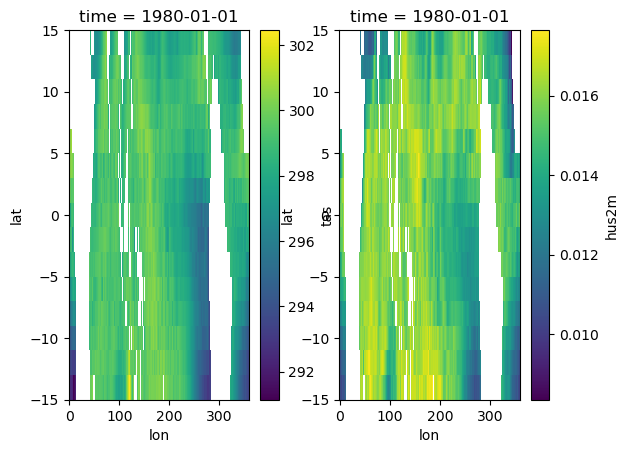

In [6]:
plt.subplot(1,2,1)
tas2m_cntl_ocean.tas[0].plot()
plt.subplot(1,2,2)
hus2m_cntl_ocean.hus2m[0].plot()

In [7]:

def esat(t, p):
    """
    usage: es = qsat(t,p)
    Returns saturation vapor pressure es (mb) given t(K) and p(mb).

    After Buck, 1981: J.Appl.Meteor., 20, 1527-1532

    Returns ndarray float for any numeric object input.
    """
    t2 = t-273.15
    return 6.1121 * np.exp(17.502 * t2 / (240.97 + t2)) * (1.0007 + p * 3.46e-6)

def q_sat(t, p):
    

    # compute saturation specific humidity
    # p is pressure in mb (hPa) -> at the surface, p is surface pressure
    # t is SST in deg K

    # compute saturation pressure
    es = esat(t, p)
    epsilon = 0.622
    return epsilon * es / p

def q_from_rh(t,p,rh, epsilon=0.622):

  # compute air specific humidity -> you should already have this variable as ICON output!

    '''
    usage:
    t in K
    p in hPa or mb
    rh : relative humidity in fraction between 0 and 1
    returns: q in kg/kg
    '''

    e_star = esat(t,p)
    e = rh*e_star
    return epsilon*e/p

def saturation_water_vapor_pressure(t2m):
    """
    Calculate saturation water vapor pressure over liquid water using the
    Tetens formula.

    Parameters:
    t : float or ndarray
        Temperature in Kelvin.

    Returns:
    es : float or ndarray
        Saturation water vapor pressure in hPa.
    """

    e0 = 6.112
    Lv = 2.5e6  # J/kg
    Rv = 461.5  # J/(kg·K)
    es = e0 * np.exp(Lv/Rv * (1/273.15 - 1/t2m))
    return es
  
  
def compute_saturation_specific_humidity(t2m, p):
    """
    Calculate saturation specific humidity.

    Parameters:
    t2m : float or ndarray
        Temperature in Kelvin.
    p : float or ndarray
        Pressure in hPa.

    Returns:
    qsat : float or ndarray
        Saturation specific humidity in kg/kg.
    """
    epsilon = 0.622
    es = saturation_water_vapor_pressure(t2m)
    qsat = epsilon * es / p
    return qsat

In [8]:
saturation_specific_humidity_cntl = q_sat(tas2m_cntl_ocean['tas'],pre_cntl['ps']/100,)
saturation_specific_humidity_p4k  = q_sat(tas2m_p4k_ocean['tas'],pre_p4k['ps']/100,)
saturation_specific_humidity_4co2 = q_sat(tas2m_4co2_ocean['tas'],pre_4co2['ps']/100,)


In [9]:
air_specific_humidity_cntl = hus2m_cntl_ocean['hus2m']
air_specific_humidity_4co2 = hus2m_4co2_ocean['hus2m']
air_specific_humidity_p4k = hus2m_p4k_ocean['hus2m']

In [10]:

print("Calculating humidity gradient (dq = qs - qa)...")

# Control 实验
dq_cntl = saturation_specific_humidity_cntl - air_specific_humidity_cntl

# 4CO2 实验
dq_4co2 = saturation_specific_humidity_4co2 - air_specific_humidity_4co2

# P4K 实验
dq_p4k = saturation_specific_humidity_p4k - air_specific_humidity_p4k

print("\nHumidity gradient calculated!")
print(f"Control dq range: {float(dq_cntl.min()):.6f} to {float(dq_cntl.max()):.6f} kg/kg")
print(f"4CO2 dq range: {float(dq_4co2.min()):.6f} to {float(dq_4co2.max()):.6f} kg/kg")
print(f"P4K dq range: {float(dq_p4k.min()):.6f} to {float(dq_p4k.max()):.6f} kg/kg")

Calculating humidity gradient (dq = qs - qa)...

Humidity gradient calculated!
Control dq range: -0.000047 to 0.022234 kg/kg
4CO2 dq range: -0.000064 to 0.022359 kg/kg
P4K dq range: -0.000139 to 0.029999 kg/kg


In [11]:
# 计算热带海洋平均值 (使用已有的 ocean_mask)

print("Calculating tropical ocean mean values...")
qs_cntl_trop_ocean = saturation_specific_humidity_cntl.where(_ocean(saturation_specific_humidity_cntl) == 1)
qs_4co2_trop_ocean = saturation_specific_humidity_4co2.where(_ocean(saturation_specific_humidity_4co2) == 1)
qs_p4k_trop_ocean = saturation_specific_humidity_p4k.where(_ocean(saturation_specific_humidity_p4k) == 1)

qa_cntl_trop_ocean = air_specific_humidity_cntl.where(_ocean(air_specific_humidity_cntl) == 1)
qa_4co2_trop_ocean = air_specific_humidity_4co2.where(_ocean(air_specific_humidity_4co2) == 1)
qa_p4k_trop_ocean = air_specific_humidity_p4k.where(_ocean(air_specific_humidity_p4k) == 1)

dq_cntl_trop_ocean = dq_cntl.where(_ocean(dq_cntl)   == 1)
dq_4co2_trop_ocean = dq_4co2.where(_ocean(dq_4co2) == 1)
dq_p4k_trop_ocean = dq_p4k.where(_ocean(dq_p4k) == 1)

# 计算热带海洋平均
qs_cntl_trop_mean = float(qs_cntl_trop_ocean.mean(skipna=True))
qs_4co2_trop_mean = float(qs_4co2_trop_ocean.mean(skipna=True))
qs_p4k_trop_mean = float(qs_p4k_trop_ocean.mean(skipna=True))

qa_cntl_trop_mean = float(qa_cntl_trop_ocean.mean(skipna=True))
qa_4co2_trop_mean = float(qa_4co2_trop_ocean.mean(skipna=True))
qa_p4k_trop_mean = float(qa_p4k_trop_ocean.mean(skipna=True))

dq_cntl_trop_mean = float(dq_cntl_trop_ocean.mean(skipna=True))
dq_4co2_trop_mean = float(dq_4co2_trop_ocean.mean(skipna=True))
dq_p4k_trop_mean = float(dq_p4k_trop_ocean.mean(skipna=True))

print("\n=== Tropical Ocean Mean Values ===")
print(f"\nControl:")
print(f"  qs = {qs_cntl_trop_mean:.6f} kg/kg")
print(f"  qa = {qa_cntl_trop_mean:.6f} kg/kg")
print(f"  dq = {dq_cntl_trop_mean:.6f} kg/kg")

print(f"\n4CO2:")
print(f"  qs = {qs_4co2_trop_mean:.6f} kg/kg")
print(f"  qa = {qa_4co2_trop_mean:.6f} kg/kg")
print(f"  dq = {dq_4co2_trop_mean:.6f} kg/kg")

print(f"\nP4K:")
print(f"  qs = {qs_p4k_trop_mean:.6f} kg/kg")
print(f"  qa = {qa_p4k_trop_mean:.6f} kg/kg")
print(f"  dq = {dq_p4k_trop_mean:.6f} kg/kg")

Calculating tropical ocean mean values...

=== Tropical Ocean Mean Values ===

Control:
  qs = 0.020103 kg/kg
  qa = 0.015219 kg/kg
  dq = 0.004884 kg/kg

4CO2:
  qs = 0.020350 kg/kg
  qa = 0.015552 kg/kg
  dq = 0.004798 kg/kg

P4K:
  qs = 0.025670 kg/kg
  qa = 0.019782 kg/kg
  dq = 0.005887 kg/kg


In [12]:
# 计算变化量和相对变化

print("\n=== Changes relative to Control ===")

# 4CO2 - Control
dqs_4co2 = qs_4co2_trop_mean - qs_cntl_trop_mean
dqa_4co2 = qa_4co2_trop_mean - qa_cntl_trop_mean
ddq_4co2 = dq_4co2_trop_mean - dq_cntl_trop_mean

# P4K - Control
dqs_p4k = qs_p4k_trop_mean - qs_cntl_trop_mean
dqa_p4k = qa_p4k_trop_mean - qa_cntl_trop_mean
ddq_p4k = dq_p4k_trop_mean - dq_cntl_trop_mean

print(f"\n4CO2 changes:")
print(f"  Δqs = {dqs_4co2:.6f} kg/kg ({dqs_4co2/qs_cntl_trop_mean*100:.2f}%)")
print(f"  Δqa = {dqa_4co2:.6f} kg/kg ({dqa_4co2/qa_cntl_trop_mean*100:.2f}%)")
print(f"  Δdq = {ddq_4co2:.6f} kg/kg ({ddq_4co2/dq_cntl_trop_mean*100:.2f}%)")

print(f"\nP4K changes:")
print(f"  Δqs = {dqs_p4k:.6f} kg/kg ({dqs_p4k/qs_cntl_trop_mean*100:.2f}%)")
print(f"  Δqa = {dqa_p4k:.6f} kg/kg ({dqa_p4k/qa_cntl_trop_mean*100:.2f}%)")
print(f"  Δdq = {ddq_p4k:.6f} kg/kg ({ddq_p4k/dq_cntl_trop_mean*100:.2f}%)")


=== Changes relative to Control ===

4CO2 changes:
  Δqs = 0.000248 kg/kg (1.23%)
  Δqa = 0.000333 kg/kg (2.19%)
  Δdq = -0.000086 kg/kg (-1.76%)

P4K changes:
  Δqs = 0.005567 kg/kg (27.69%)
  Δqa = 0.004564 kg/kg (29.99%)
  Δdq = 0.001003 kg/kg (20.54%)


In [13]:
lon = saturation_specific_humidity_cntl['lon'] 
lat = saturation_specific_humidity_cntl['lat'] 
qs_cntl_mean = qs_cntl_trop_ocean.mean(dim='time', skipna=True) 
qs_4co2_mean = qs_4co2_trop_ocean.mean(dim='time', skipna=True) 
qs_p4k_mean = qs_p4k_trop_ocean.mean(dim='time', skipna=True) 
qa_cntl_mean = qa_cntl_trop_ocean.mean(dim='time', skipna=True) 
qa_4co2_mean = qa_4co2_trop_ocean.mean(dim='time', skipna=True) 
qa_p4k_mean = qa_p4k_trop_ocean.mean(dim='time', skipna=True) 
dq_cntl_mean = dq_cntl_trop_ocean.mean(dim='time', skipna=True) 
dq_4co2_mean = dq_4co2_trop_ocean.mean(dim='time', skipna=True) 
dq_p4k_mean = dq_p4k_trop_ocean.mean(dim='time', skipna=True)

# 绘制空间分布图：qs, qa, 和 dq 的气候态和变化

Color ranges:
  qs: 12.97 - 31.04 g/kg
  qa: 10.40 - 22.08 g/kg
  dq: 1.09 - 12.74 g/kg


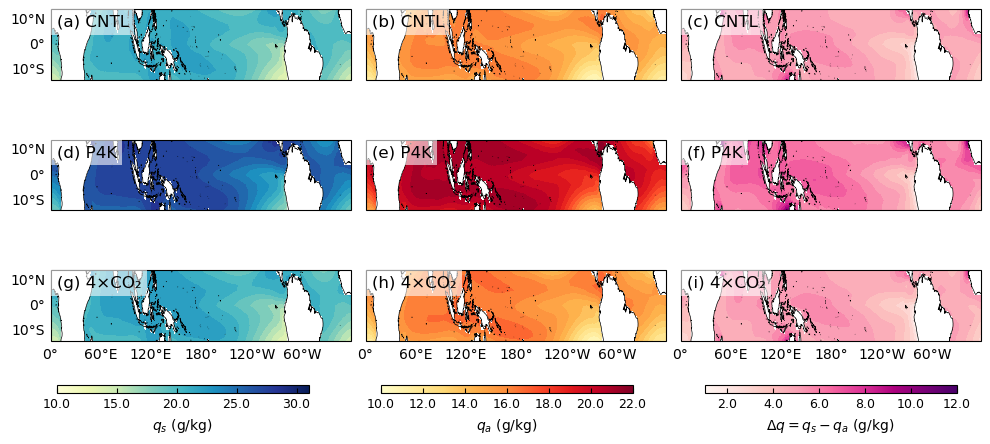

✅ Climatological figure saved successfully!


In [14]:

# === 基础设置 ===
fig, axes = plt.subplots(3, 3, figsize=(12, 5), sharex=True, sharey=True,
                         subplot_kw={'projection': ccrs.PlateCarree(180)})
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# === colormap 设置 ===
cmap_qs = 'YlGnBu'      # 饱和比湿用蓝绿色系
cmap_qa = 'YlOrRd'      # 空气比湿用橙红色系  
cmap_dq = 'RdPu'        # 湿度梯度用紫红色系
unit_factor = 1000  # 转为 g/kg

# === 数据 ===
experiments = {
    "CNTL": [qs_cntl_mean, qa_cntl_mean, qs_cntl_mean - qa_cntl_mean],
    "P4K":     [qs_p4k_mean,  qa_p4k_mean,  qs_p4k_mean  - qa_p4k_mean],
    "4×CO₂":    [qs_4co2_mean, qa_4co2_mean, qs_4co2_mean - qa_4co2_mean]
}

titles = [r"$q_s$ (g/kg)", r"$q_a$ (g/kg)", r"$\Delta q = q_s - q_a$ (g/kg)"]

# === 计算每列的公共色标范围 ===
# 第一列：qs (饱和比湿)
qs_all = [qs_cntl_mean, qs_p4k_mean, qs_4co2_mean]
qs_vmin = min([np.nanmin(q) for q in qs_all]) * unit_factor
qs_vmax = max([np.nanmax(q) for q in qs_all]) * unit_factor

# 第二列：qa (空气比湿)
qa_all = [qa_cntl_mean, qa_p4k_mean, qa_4co2_mean]
qa_vmin = min([np.nanmin(q) for q in qa_all]) * unit_factor
qa_vmax = max([np.nanmax(q) for q in qa_all]) * unit_factor

# 第三列：dq (湿度梯度)
dq_all = [qs_cntl_mean - qa_cntl_mean, qs_p4k_mean - qa_p4k_mean, qs_4co2_mean - qa_4co2_mean]
dq_vmin = min([np.nanmin(dq) for dq in dq_all]) * unit_factor
dq_vmax = max([np.nanmax(dq) for dq in dq_all]) * unit_factor

vlims = [(10, 31), (10, 22), (1, 12)]
cmaps_all = [cmap_qs, cmap_qa, cmap_dq]

print(f"Color ranges:")
print(f"  qs: {qs_vmin:.2f} - {qs_vmax:.2f} g/kg")
print(f"  qa: {qa_vmin:.2f} - {qa_vmax:.2f} g/kg")
print(f"  dq: {dq_vmin:.2f} - {dq_vmax:.2f} g/kg")

# === 绘制图像 ===
panel_labels = list("abcdefghi")
for i, (exp_name, data_list) in enumerate(experiments.items()):
    for j, field in enumerate(data_list):
        cmap = cmaps_all[j]
        vmin, vmax = vlims[j]
        
        # 使用统一的色标范围绘制
        im = axes[i, j].contourf(lon, lat, field*unit_factor, transform=ccrs.PlateCarree(),
                                 levels=np.linspace(vmin, vmax, 21), 
                                 cmap=cmap, extend='both',
                                 vmin=vmin, vmax=vmax)
        axes[i, j].coastlines(linewidth=0.5)
        axes[i, j].set_aspect(3)  # 设置地图纵横比
        
        # 设置地图网格线
        gl = axes[i, j].gridlines(draw_labels=True, linewidth=0., color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        
        # 只在最后一行显示经度标签
        if i < 2:   # 不是最后一行
            gl.bottom_labels = False
        else:
            gl.bottom_labels = True
            gl.xlabel_style = {'size': 10}

        # 只在第一列显示纬度标签
        if j > 0:   # 不是最左一列
            gl.left_labels = False
        else:
            gl.left_labels = True
            gl.ylabel_style = {'size': 10}
            
        # 实验标签
        axes[i, j].text(0.02, 0.93, f"({panel_labels[i*3+j]}) {exp_name}",
                        transform=axes[i, j].transAxes, fontsize=12,
                         va='top', ha='left',
                        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
  
# === 每列共用一个 colorbar ===
for j in range(3):
    cbar_ax = fig.add_axes([0.13 + j*0.27, 0.06, 0.21, 0.015])  # 手动位置
    
    # 创建一个mappable对象用于colorbar
    norm = plt.Normalize(vmin=vlims[j][0], vmax=vlims[j][1])
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmaps_all[j])
    sm.set_array([])
    
    # 绘制colorbar
    cbar = plt.colorbar(sm, cax=cbar_ax,label=titles[j], orientation='horizontal')
    # cbar_ax.set_title(titles[j], fontsize=11, fontweight='bold', pad=8)
    cbar.ax.tick_params(direction='in',labelsize=9)
    
    # 设置colorbar的刻度格式
    cbar.ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    
plt.savefig(f"{fig_save_dir}/humidity_qs_qa_dq_climatology.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Climatological figure saved successfully!")


## 绘制总体评价的bar图

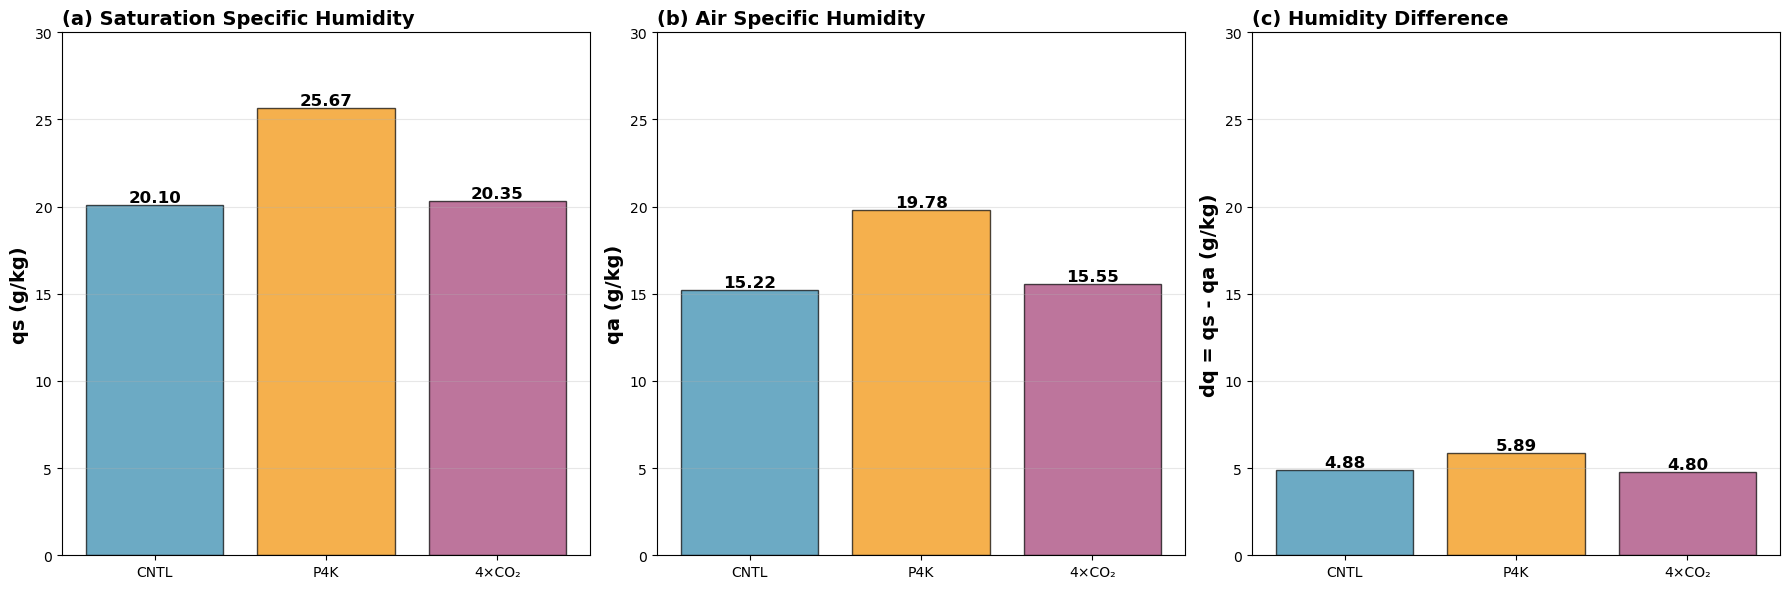

In [15]:
# 创建柱状图比较热带海洋平均的 qs, qa, dq
color_cntl = '#2E86AB'
color_p4k = '#A23B72'
color_4co2 = '#F18F01'

fig_bar2, axes_bar2 = plt.subplots(1, 3, figsize=(18, 6))


experiments_list = ['CNTL',   'P4K', '4×CO₂']
colors_list = [color_cntl, color_4co2, color_p4k]

# 准备数据
qs_values = [qs_cntl_trop_mean*1000,qs_p4k_trop_mean*1000, qs_4co2_trop_mean*1000, ]
qa_values = [qa_cntl_trop_mean*1000,  qa_p4k_trop_mean*1000,qa_4co2_trop_mean*1000,]
dq_values = [dq_cntl_trop_mean*1000,  dq_p4k_trop_mean*1000,dq_4co2_trop_mean*1000,]

# 子图1: qs
axes_bar2[0].bar(experiments_list, qs_values, color=colors_list, alpha=0.7, edgecolor='black')
axes_bar2[0].set_ylabel('qs (g/kg)', fontsize=14, fontweight='bold')
axes_bar2[0].set_title('(a) Saturation Specific Humidity', fontsize=14, fontweight='bold',loc='left')
axes_bar2[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(qs_values):
    axes_bar2[0].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes_bar2[0].set_ylim(0, 30)  # 设置相同的y轴范围
# 子图2: qa
axes_bar2[1].bar(experiments_list, qa_values, color=colors_list, alpha=0.7, edgecolor='black')
axes_bar2[1].set_ylabel('qa (g/kg)', fontsize=14, fontweight='bold')
axes_bar2[1].set_title('(b) Air Specific Humidity', fontsize=14, fontweight='bold',loc='left')
axes_bar2[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(qa_values):
    axes_bar2[1].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes_bar2[1].set_ylim(0, 30)  # 设置相同的y轴范围
# 子图3: dq
axes_bar2[2].bar(experiments_list, dq_values, color=colors_list, alpha=0.7, edgecolor='black')
axes_bar2[2].set_ylabel('dq = qs - qa (g/kg)', fontsize=14, fontweight='bold')
axes_bar2[2].set_title('(c) Humidity Difference', fontsize=14, fontweight='bold',loc='left')
axes_bar2[2].grid(axis='y', alpha=0.3)
axes_bar2[2].set_ylim(0, 30)  # 设置相同的y轴范围
for i, v in enumerate(dq_values):
    axes_bar2[2].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{fig_save_dir}/humidity_bar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 相对变化

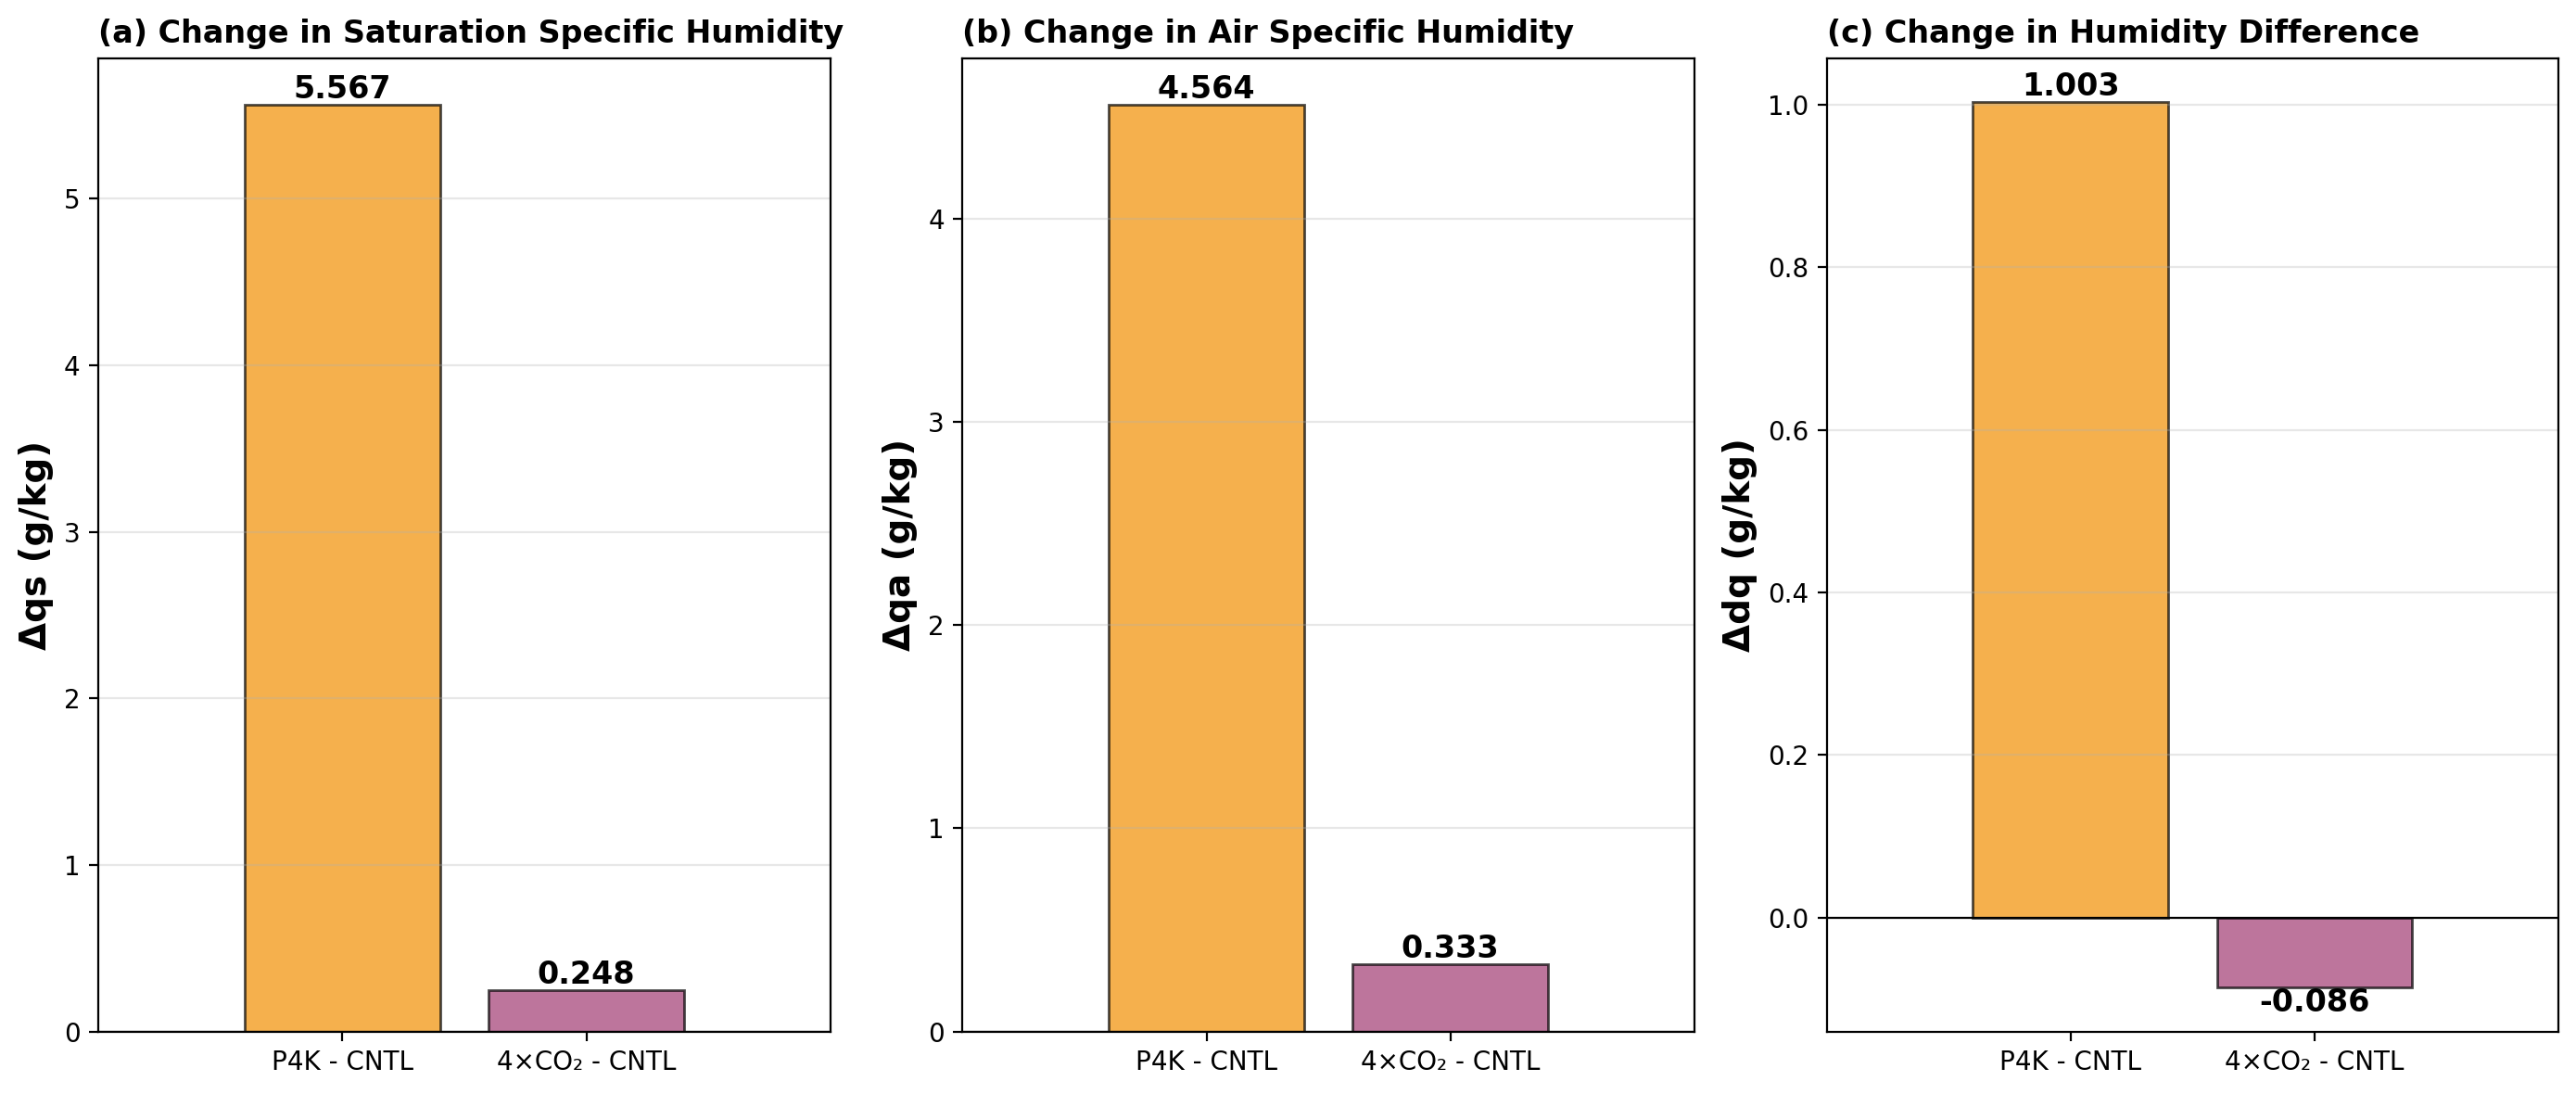

In [16]:
# 创建变化量的柱状图 (Δqs, Δqa, Δdq)

fig_bar3, axes_bar3 = plt.subplots(1, 3, figsize=(14, 6),dpi=200)

experiments_change = [r'P4K - CNTL', r'4×CO₂ - CNTL']
colors_change = [color_4co2, color_p4k]

# 准备变化量数据 (单位: g/kg)
dqs_values = [dqs_p4k*1000, dqs_4co2*1000]
dqa_values = [dqa_p4k*1000, dqa_4co2*1000]
ddq_values = [ddq_p4k*1000, ddq_4co2*1000]

# 子图1: Δqs
bars1 = axes_bar3[0].bar(experiments_change, dqs_values, color=colors_change, alpha=0.7, edgecolor='black')
axes_bar3[0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes_bar3[0].set_ylabel('Δqs (g/kg)', fontsize=14, fontweight='bold')
axes_bar3[0].set_title('(a) Change in Saturation Specific Humidity', fontsize=12, fontweight='bold',loc='left')
axes_bar3[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(dqs_values):
    axes_bar3[0].text(i, v, f'{v:.3f}', ha='center', va='bottom' if v > 0 else 'top', 
                      fontsize=12, fontweight='bold')

# 子图2: Δqa
bars2 = axes_bar3[1].bar(experiments_change, dqa_values, color=colors_change, alpha=0.7, edgecolor='black')
axes_bar3[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes_bar3[1].set_ylabel('Δqa (g/kg)', fontsize=14, fontweight='bold')
axes_bar3[1].set_title('(b) Change in Air Specific Humidity', fontsize=12, fontweight='bold',loc='left')
axes_bar3[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(dqa_values):
    axes_bar3[1].text(i, v, f'{v:.3f}', ha='center', va='bottom' if v > 0 else 'top', 
                      fontsize=12, fontweight='bold')

# 子图3: Δdq
bars3 = axes_bar3[2].bar(experiments_change, ddq_values, color=colors_change, alpha=0.7, edgecolor='black')
axes_bar3[2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes_bar3[2].set_ylabel('Δdq (g/kg)', fontsize=14, fontweight='bold')
axes_bar3[2].set_title('(c) Change in Humidity Difference', fontsize=12, fontweight='bold',loc='left')
axes_bar3[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(ddq_values):
    axes_bar3[2].text(i, v, f'{v:.3f}', ha='center', va='bottom' if v > 0 else 'top', 
                      fontsize=12, fontweight='bold')
for ax in axes_bar3:
    ax.tick_params(axis='x', labelsize=10)
    ax.set_xlim(-1, 2.)
plt.tight_layout()
plt.savefig(f'{fig_save_dir}/humidity_changes_bar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# 综合分析：对比风速和湿度因子的贡献

print("="*80)
print("潜热通量因子综合分析")
print("="*80)
print("\n潜热通量公式: LHF = ρ * Lv * Ce * U * (qs - qa)")
print("\n其中：")
print("  - U: 表面风速")
print("  - qs: 海表饱和比湿 (取决于SST)")
print("  - qa: 近地表空气比湿")
print("  - dq = qs - qa: 湿度梯度")

print("\n" + "="*80)
print("热带海洋平均值 (30°S-30°N)")
print("="*80)



print("\n2. 饱和比湿 (qs):")
print(f"   Control:  {qs_cntl_trop_mean*1000:.2f} g/kg")
print(f"   4CO2:     {qs_4co2_trop_mean*1000:.2f} g/kg  (变化: {(qs_4co2_trop_mean-qs_cntl_trop_mean)*1000:.3f} g/kg, {(qs_4co2_trop_mean-qs_cntl_trop_mean)/qs_cntl_trop_mean*100:.2f}%)")
print(f"   P4K:      {qs_p4k_trop_mean*1000:.2f} g/kg  (变化: {(qs_p4k_trop_mean-qs_cntl_trop_mean)*1000:.3f} g/kg, {(qs_p4k_trop_mean-qs_cntl_trop_mean)/qs_cntl_trop_mean*100:.2f}%)")

print("\n3. 空气比湿 (qa):")
print(f"   Control:  {qa_cntl_trop_mean*1000:.2f} g/kg")
print(f"   4CO2:     {qa_4co2_trop_mean*1000:.2f} g/kg  (变化: {(qa_4co2_trop_mean-qa_cntl_trop_mean)*1000:.3f} g/kg, {(qa_4co2_trop_mean-qa_cntl_trop_mean)/qa_cntl_trop_mean*100:.2f}%)")
print(f"   P4K:      {qa_p4k_trop_mean*1000:.2f} g/kg  (变化: {(qa_p4k_trop_mean-qa_cntl_trop_mean)*1000:.3f} g/kg, {(qa_p4k_trop_mean-qa_cntl_trop_mean)/qa_cntl_trop_mean*100:.2f}%)")

print("\n4. 湿度梯度 (dq = qs - qa):")
print(f"   Control:  {dq_cntl_trop_mean*1000:.2f} g/kg")
print(f"   4CO2:     {dq_4co2_trop_mean*1000:.2f} g/kg  (变化: {(dq_4co2_trop_mean-dq_cntl_trop_mean)*1000:.3f} g/kg, {(dq_4co2_trop_mean-dq_cntl_trop_mean)/dq_cntl_trop_mean*100:.2f}%)")
print(f"   P4K:      {dq_p4k_trop_mean*1000:.2f} g/kg  (变化: {(dq_p4k_trop_mean-dq_cntl_trop_mean)*1000:.3f} g/kg, {(dq_p4k_trop_mean-dq_cntl_trop_mean)/dq_cntl_trop_mean*100:.2f}%)")

print("\n" + "="*80)
print("关键发现")
print("="*80)

print("\n【4CO2 实验】:")

print(f"  • qs变化:       {(qs_4co2_trop_mean-qs_cntl_trop_mean)/qs_cntl_trop_mean*100:+.2f}%  (几乎无变化)")
print(f"  • qa变化:       {(qa_4co2_trop_mean-qa_cntl_trop_mean)/qa_cntl_trop_mean*100:+.2f}%  (小幅增加)")
print(f"  • dq变化:       {(dq_4co2_trop_mean-dq_cntl_trop_mean)/dq_cntl_trop_mean*100:+.2f}%  (减少 - 关键!)")
print("  结论: 4CO2中，qa增加快于qs，导致湿度梯度dq减小，这会减少潜热通量！")

print("\n【P4K 实验】:")

print(f"  • qs变化:       {(qs_p4k_trop_mean-qs_cntl_trop_mean)/qs_cntl_trop_mean*100:+.2f}%  (显著增加)")
print(f"  • qa变化:       {(qa_p4k_trop_mean-qa_cntl_trop_mean)/qa_cntl_trop_mean*100:+.2f}%  (大幅增加)")
print(f"  • dq变化:       {(dq_p4k_trop_mean-dq_cntl_trop_mean)/dq_cntl_trop_mean*100:+.2f}%  (增加)")
print("  结论: P4K中，qs和qa都大幅增加，但qs增加更快(SST升高4K)，导致湿度梯度dq增大！")

print("\n" + "="*80)
print("总结")
print("="*80)
print("""
1. 表面风速在两个实验中都略有减少（~1-2%），不是主导因子

2. 湿度梯度(dq = qs - qa)才是关键：
   - 4CO2: dq减少4.46%，这会减少潜热通量
   - P4K:  dq增加17.55%，这会增加潜热通量

3. 机制分析：
   • 在4CO2中：虽然SST略有变化，但大气比湿qa增加快于qs，
     导致海-气湿度差减小，抑制了潜热通量
   
   • 在P4K中：SST大幅升高(+4K)，使得qs大幅增加（Clausius-Clapeyron关系），
     尽管qa也增加，但qs增加更快，导致海-气湿度差增大，增强了潜热通量

4. 这说明潜热通量的变化主要由**湿度梯度(qs-qa)**控制，
   而不是由风速控制！
""")

潜热通量因子综合分析

潜热通量公式: LHF = ρ * Lv * Ce * U * (qs - qa)

其中：
  - U: 表面风速
  - qs: 海表饱和比湿 (取决于SST)
  - qa: 近地表空气比湿
  - dq = qs - qa: 湿度梯度

热带海洋平均值 (30°S-30°N)

2. 饱和比湿 (qs):
   Control:  20.10 g/kg
   4CO2:     20.35 g/kg  (变化: 0.248 g/kg, 1.23%)
   P4K:      25.67 g/kg  (变化: 5.567 g/kg, 27.69%)

3. 空气比湿 (qa):
   Control:  15.22 g/kg
   4CO2:     15.55 g/kg  (变化: 0.333 g/kg, 2.19%)
   P4K:      19.78 g/kg  (变化: 4.564 g/kg, 29.99%)

4. 湿度梯度 (dq = qs - qa):
   Control:  4.88 g/kg
   4CO2:     4.80 g/kg  (变化: -0.086 g/kg, -1.76%)
   P4K:      5.89 g/kg  (变化: 1.003 g/kg, 20.54%)

关键发现

【4CO2 实验】:
  • qs变化:       +1.23%  (几乎无变化)
  • qa变化:       +2.19%  (小幅增加)
  • dq变化:       -1.76%  (减少 - 关键!)
  结论: 4CO2中，qa增加快于qs，导致湿度梯度dq减小，这会减少潜热通量！

【P4K 实验】:
  • qs变化:       +27.69%  (显著增加)
  • qa变化:       +29.99%  (大幅增加)
  • dq变化:       +20.54%  (增加)
  结论: P4K中，qs和qa都大幅增加，但qs增加更快(SST升高4K)，导致湿度梯度dq增大！

总结

1. 表面风速在两个实验中都略有减少（~1-2%），不是主导因子

2. 湿度梯度(dq = qs - qa)才是关键：
   - 4CO2: dq减少4.46%，这会减少潜热通量
   - P4K:  d

## 风速和水汽的变化分析

### 风速的气候态平均

In [18]:
wind_data_dir = "/work/mh1498/m301257/processed_data/2d_layers"

print("="*70)
print("Loading surface wind speed data...")
print("="*70)

# Load CNTL
sfcwind_cntl_path = f"{wind_data_dir}/sfcwind_cntl/sfcwind_2deg_interp.nc"
sfcwind_cntl = xr.open_dataset(sfcwind_cntl_path)

print(f"\n✅ CNTL loaded from: {sfcwind_cntl_path}")
print(sfcwind_cntl)

# Load P4K
sfcwind_p4k_path = f"{wind_data_dir}/sfcwind_p4k/sfcwind_2deg_interp.nc"
sfcwind_p4k = xr.open_dataset(sfcwind_p4k_path)
print(f"\n✅ P4K loaded from: {sfcwind_p4k_path}")
print(sfcwind_p4k)

# Load 4CO2
sfcwind_4co2_path = f"{wind_data_dir}/sfcwind_4co2/sfcwind_2deg_interp.nc"
sfcwind_4co2 = xr.open_dataset(sfcwind_4co2_path)
print(f"\n✅ 4CO2 loaded from: {sfcwind_4co2_path}")
print(sfcwind_4co2)

print("\n" + "="*70)
print("Data Summary:")
print("="*70)
print(f"CNTL shape:  {sfcwind_cntl.sfcwind.shape}")
print(f"P4K shape:   {sfcwind_p4k.sfcwind.shape}")
print(f"4CO2 shape:  {sfcwind_4co2.sfcwind.shape}")

# Calculate time mean and basic statistics
print("="*70)
print("Calculating time mean and statistics...")
print("="*70)

# Time mean
sfcwind_cntl_mean = sfcwind_cntl.sfcwind.mean(dim='time')
sfcwind_p4k_mean = sfcwind_p4k.sfcwind.mean(dim='time')
sfcwind_4co2_mean = sfcwind_4co2.sfcwind.mean(dim='time')

# Calculate changes of time mean
wind_change_p4k = sfcwind_p4k_mean - sfcwind_cntl_mean
wind_change_4co2 = sfcwind_4co2_mean - sfcwind_cntl_mean


print("\n" + "="*80)

print("="*80)
### mask ocean data
print("Masking ocean data for surface wind speed...")
sfcwind_cntl_mean_ocean = sfcwind_cntl_mean.where(_ocean(sfcwind_cntl_mean) == 1)
sfcwind_p4k_mean_ocean = sfcwind_p4k_mean.where(_ocean(sfcwind_p4k_mean) == 1)
sfcwind_4co2_mean_ocean = sfcwind_4co2_mean.where(_ocean(sfcwind_4co2_mean) == 1)
### calculate difference over tropics ocean
wind_change_p4k_ocean = wind_change_p4k.where(_ocean(wind_change_p4k) == 1)
wind_change_4co2_ocean = wind_change_4co2.where(_ocean(wind_change_4co2) == 1)


print("-" * 80)
sfcwind_cntl_mean = sfcwind_cntl_mean_ocean.mean().values
sfcwind_p4k_mean = sfcwind_p4k_mean_ocean.mean().values
sfcwind_4co2_mean = sfcwind_4co2_mean_ocean.mean().values


Loading surface wind speed data...

✅ CNTL loaded from: /work/mh1498/m301257/processed_data/2d_layers/sfcwind_cntl/sfcwind_2deg_interp.nc
<xarray.Dataset> Size: 111MB
Dimensions:  (time: 5114, lat: 15, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    sfcwind  (time, lat, lon) float64 110MB ...

✅ P4K loaded from: /work/mh1498/m301257/processed_data/2d_layers/sfcwind_p4k/sfcwind_2deg_interp.nc
<xarray.Dataset> Size: 111MB
Dimensions:  (time: 5114, lat: 15, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    sfcwind  (time, lat, lon) float64 1

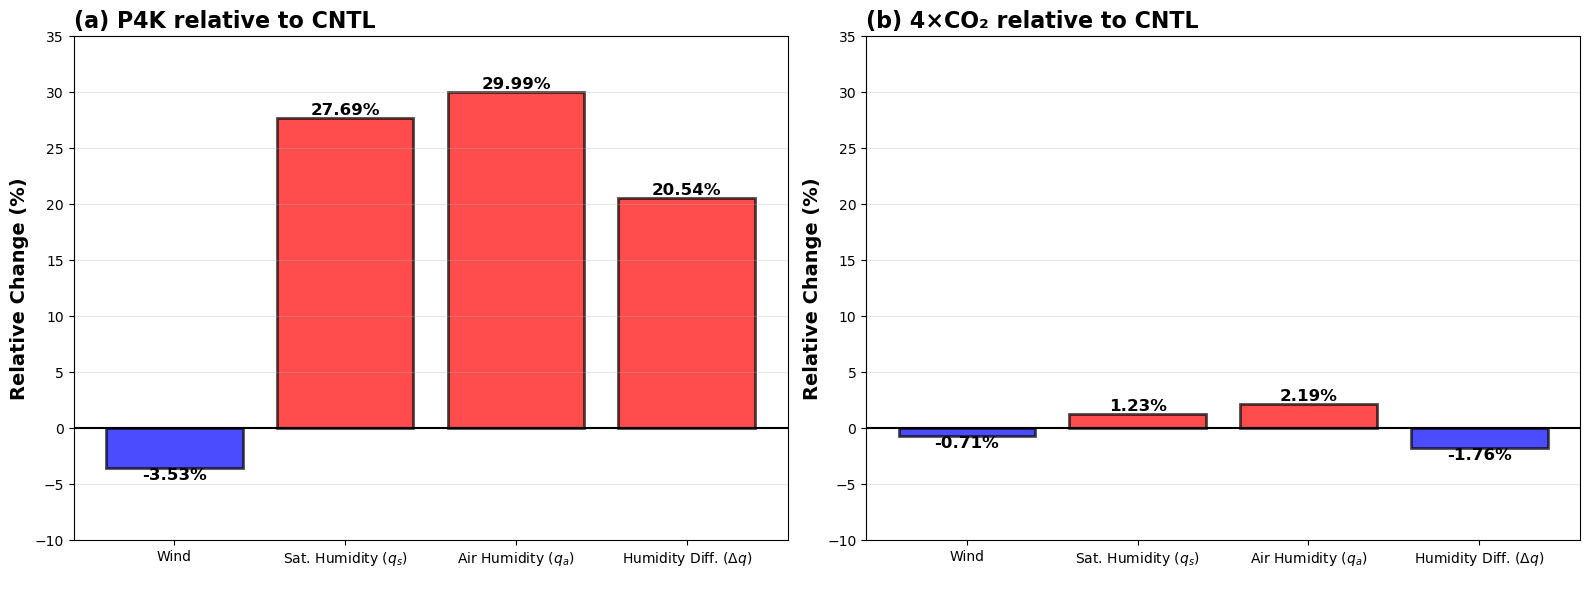

✅ Summary figure saved successfully!


In [29]:
# 创建总结图：所有因子的相对变化百分比
# 4CO2实验的变化（使用全球平均值）
factors = ['Wind\n', r'Sat. Humidity ($q_s$)', r'Air Humidity ($q_a$)', r'Humidity Diff. ($\Delta q$)']
fig_summary, (ax2, ax1) = plt.subplots(1, 2, figsize=(16, 6))


# P4K实验的变化（使用全球平均值）
changes_p4k = [
    (sfcwind_p4k_mean - sfcwind_cntl_mean) / sfcwind_cntl_mean * 100,
    (qs_p4k_trop_mean - qs_cntl_trop_mean) / qs_cntl_trop_mean * 100,
    (qa_p4k_trop_mean - qa_cntl_trop_mean) / qa_cntl_trop_mean * 100,
    (dq_p4k_trop_mean - dq_cntl_trop_mean) / dq_cntl_trop_mean * 100
]

colors_p4k_bars = ['blue' if x < 0 else 'red' for x in changes_p4k]

bars2 = ax2.bar(factors, changes_p4k, color=colors_p4k_bars, alpha=0.7, edgecolor='black', linewidth=2)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax2.set_ylabel('Relative Change (%)', fontsize=14, fontweight='bold')
ax2.set_title('(a) P4K relative to CNTL', fontsize=16, fontweight='bold', loc='left')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(-10, 35)

# 添加数值标签
for i, (bar, v) in enumerate(zip(bars2, changes_p4k)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{v:.2f}%',
             ha='center', va='bottom' if height > 0 else 'top',
             fontsize=12, fontweight='bold')



changes_4co2 = [
    (sfcwind_4co2_mean - sfcwind_cntl_mean) / sfcwind_cntl_mean * 100,
    (qs_4co2_trop_mean - qs_cntl_trop_mean) / qs_cntl_trop_mean * 100,
    (qa_4co2_trop_mean - qa_cntl_trop_mean) / qa_cntl_trop_mean * 100,
    (dq_4co2_trop_mean - dq_cntl_trop_mean) / dq_cntl_trop_mean * 100
]

colors_4co2_bars = ['blue' if x < 0 else 'red' for x in changes_4co2]

bars1 = ax1.bar(factors, changes_4co2, color=colors_4co2_bars, alpha=0.7, edgecolor='black', linewidth=2)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax1.set_ylabel('Relative Change (%)', fontsize=14, fontweight='bold')
ax1.set_title('(b) 4×CO₂ relative to CNTL', fontsize=16, fontweight='bold', loc='left')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(-10, 35)

# 添加数值标签
for i, (bar, v) in enumerate(zip(bars1, changes_4co2)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{v:.2f}%',
             ha='center', va='bottom' if height > 0 else 'top',
             fontsize=12, fontweight='bold')


#
plt.tight_layout()
plt.savefig(f'{fig_save_dir}/latent_heat_factors_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Summary figure saved successfully!")

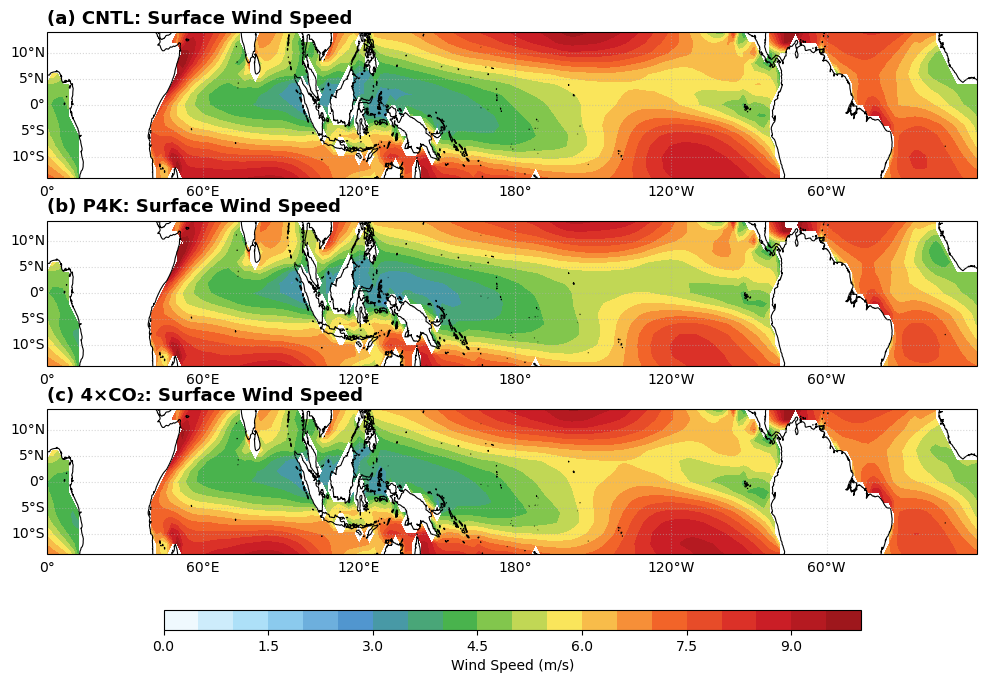

In [25]:


# ============================================================================
# Figure 1: Climatology (3 experiments)
# ============================================================================
fig1, axes1 = plt.subplots(3,1, figsize=(12, 9), 
                           subplot_kw={'projection': ccrs.PlateCarree(180)})

vmin_clim, vmax_clim = 0, 10
windcmap = cmaps.WhiteBlueGreenYellowRed
# CNTL climatology
ax = axes1[0]
ax.set_aspect(2)
im = ax.contourf(sfcwind_cntl_mean_ocean.lon, sfcwind_cntl_mean_ocean.lat, 
                 sfcwind_cntl_mean_ocean, transform = ccrs.PlateCarree(),
                 levels=np.linspace(vmin_clim, vmax_clim, 21), cmap=windcmap, extend='neither')
ax.coastlines(linewidth=0.8)

ax.set_title('(a) CNTL: Surface Wind Speed', fontsize=13,loc='left', fontweight='bold')
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# P4K climatology
ax = axes1[1]
ax.set_aspect(2)
im = ax.contourf(sfcwind_p4k_mean_ocean.lon, sfcwind_p4k_mean_ocean.lat,
                 sfcwind_p4k_mean_ocean,transform = ccrs.PlateCarree(),
                 levels=np.linspace(vmin_clim, vmax_clim, 21), cmap=windcmap, extend='neither')
ax.coastlines(linewidth=0.8)

ax.set_title('(b) P4K: Surface Wind Speed', fontsize=13,loc='left', fontweight='bold')
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# 4CO2 climatology
ax = axes1[2]
ax.set_aspect(2)
im = ax.contourf(sfcwind_4co2_mean_ocean.lon, sfcwind_4co2_mean_ocean.lat,
                 sfcwind_4co2_mean_ocean,transform = ccrs.PlateCarree(),
                 levels=np.linspace(vmin_clim, vmax_clim, 21), cmap=windcmap, extend='neither')
ax.coastlines(linewidth=0.8)

ax.set_title('(c) 4×CO₂: Surface Wind Speed', fontsize=13, loc='left',fontweight='bold')
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.colorbar(im, ax=axes1, orientation='horizontal', pad=0.08, label='Wind Speed (m/s)', shrink=0.75,aspect=35)

# fig1.savefig(f'{fig_save_dir}/wind_climatology.png', dpi=300, bbox_inches='tight')
# print(f"✅ Figure 1 saved: {fig_save_dir}/wind_climatology.png")
plt.show()

# ============================================================================
# Figure 2: Changes (P4K-CNTL and 4CO2-CNTL)
# ============================================================================
# fig2, axes2 = plt.subplots(2, 1, figsize=(12, 6),
#                            subplot_kw={'projection': ccrs.PlateCarree(180)})

# vmin_change, vmax_change = -2, 2

# # P4K - CNTL
# ax = axes2[0]
# ax.set_aspect(2)
# im = ax.contourf(wind_change_p4k_ocean.lon, wind_change_p4k_ocean.lat,
#                  wind_change_p4k_ocean, transform = ccrs.PlateCarree(),
#                  levels=np.linspace(vmin_change, vmax_change, 21), cmap='RdBu_r', extend='neither')
# ax.coastlines(linewidth=0.8)
# ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)

# ocean_mean_p4k = wind_change_p4k_ocean.mean().values
# ax.set_title(f'(a) P4K - CNTL', loc='left',
#              fontsize=13, fontweight='bold')
# gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
# gl.top_labels = False
# gl.right_labels = False

# # 4CO2 - CNTL
# ax = axes2[1]
# ax.set_aspect(2)
# im = ax.contourf(wind_change_4co2_ocean.lon, wind_change_4co2_ocean.lat,
#                  wind_change_4co2_ocean,transform = ccrs.PlateCarree(),
#                  levels=np.linspace(vmin_change, vmax_change, 21), cmap='RdBu_r', extend='neither')
# ax.coastlines(linewidth=0.8)
# ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)

# ocean_mean_4co2 = wind_change_4co2_ocean.mean().values
# ax.set_title(f'(b) 4×CO₂ - CNTL', loc='left',
#              fontsize=13, fontweight='bold')
# gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5)
# gl.top_labels = False
# gl.right_labels = False
# plt.colorbar(im, ax=axes2, orientation='horizontal', pad=0.08, label='Δ Wind Speed (m/s)', shrink=0.75,aspect=35)


# fig2.savefig(f'{fig_save_dir}/wind_changes.png', dpi=300, bbox_inches='tight')
# print(f"✅ Figure 2 saved: {fig_save_dir}/wind_changes.png")
# plt.show()

